In [1]:
import pandas as pd

In [2]:
nav = pd.read_csv("G:/bluestock_mf_capstone/data/raw/02_nav_history.csv")
aum = pd.read_csv("G:/bluestock_mf_capstone/data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("G:/bluestock_mf_capstone/data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("G:/bluestock_mf_capstone/data/raw/05_category_inflows.csv")
folio = pd.read_csv("G:/bluestock_mf_capstone/data/raw/06_industry_folio_count.csv")
transactions = pd.read_csv("G:/bluestock_mf_capstone/data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("G:/bluestock_mf_capstone/data/raw/09_portfolio_holdings.csv")

In [3]:
datasets = {
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Transactions": transactions,
    "Holdings": holdings
}

In [4]:
for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print(df.columns.tolist())
    print(df.head())


NAV
['amfi_code', 'date', 'nav']
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                      

In [5]:
nav["amfi_code"].nunique()

fund_master = pd.read_csv("G:/bluestock_mf_capstone/data/raw/01_fund_master.csv")

print(fund_master.columns.tolist())
print(fund_master.head())

print("\nNumber of unique schemes:")
print(nav["amfi_code"].nunique())

print("\nUnique AMFI Codes:")
print(nav["amfi_code"].unique())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 S

In [6]:
fund_master = pd.read_csv("G:/bluestock_mf_capstone/data/raw/01_fund_master.csv")

print("\nFund Master Columns:")
print(fund_master.columns.tolist())

print("\nFund Master Head:")
print(fund_master.head())


Fund Master Columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

Fund Master Head:
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small

In [7]:
# EDA ANALYSIS - BLUESTOCK CAPSTONE

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Create output folder
os.makedirs(
    "G:/bluestock_mf_capstone/reports/charts",
    exist_ok=True
)

## Insight 1

Most mutual fund schemes showed a steady increase in NAV during 2023, indicating strong market performance and investor confidence.

**Reference:** Chart 01 – Daily NAV Trend for All Mutual Fund Schemes

In [8]:
# CHART 01- NAV Trend Analysis

import plotly.express as px

# Convert date column into datetime format
nav["date"] = pd.to_datetime(nav["date"])

# Merge scheme names with NAV data
nav_data = pd.merge(
    nav,
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Create line chart
fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend for All Mutual Fund Schemes"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.2,
    annotation_text="2023 Bull Run"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.2,
    annotation_text="2024 Correction"
)

# Show chart
fig.show()

# Save chart
fig.write_image(
    "G:/bluestock_mf_capstone/reports/charts/chart_01_nav_trend.png"
)

print("Chart 01 Created Successfully")

Chart 01 Created Successfully


## Insight 2

Assets Under Management (AUM) increased consistently across fund houses, with leading fund houses contributing the largest share of industry growth.

**Reference:** Chart 02 – AUM Growth by Fund House

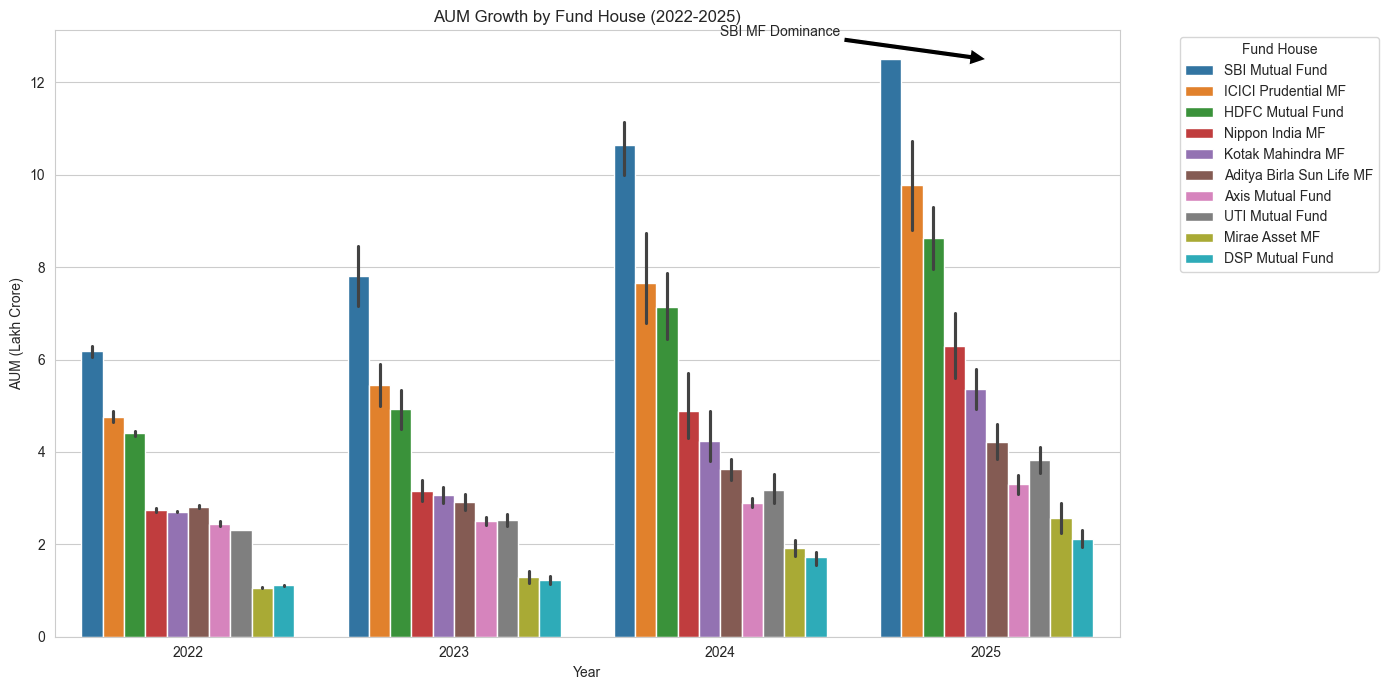

Chart 02 Created Successfully


In [9]:
# CHART 02 - AUM GROWTH BY FUND HOUSE

import matplotlib.pyplot as plt
import seaborn as sns

# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Create chart
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

# Highlight SBI dominance
plt.annotate(
    "SBI MF Dominance",
    xy=(3, 12.5),
    xytext=(2, 13),
    arrowprops=dict(facecolor="black")
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.05,1))

plt.tight_layout()

# Save chart
plt.savefig(
    "G:/bluestock_mf_capstone/reports/charts/chart_02_aum_growth.png"
)

plt.show()

print("Chart 02 Created Successfully")

## Insight 3

Monthly SIP inflows reached record highs during the study period, demonstrating increasing participation from retail investors.

**Reference:** Chart 03 – Monthly SIP Inflow Trend

In [10]:
# CHART 03 - SIP INFLOW TIME SERIES (2022–2025)

import plotly.express as px

# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Find highest SIP inflow
highest_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

# Create chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022-2025)"
)

# Add annotation
fig.add_annotation(
    x=str(highest_sip["month"].date()),
    y=highest_sip["sip_inflow_crore"],
    text=f"All-Time High ₹{highest_sip['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

# Save as HTML (safer than PNG)
fig.write_image(
    "G:/bluestock_mf_capstone/reports/charts/chart_03_sip_inflow_trend.png"
)

print("Chart 03 Created Successfully")

Chart 03 Created Successfully


## Insight 4

Certain mutual fund categories attracted significantly higher inflows than others, indicating changing investor preferences over time.

**Reference:** Chart 04 – Category-wise Net Inflow Heatmap

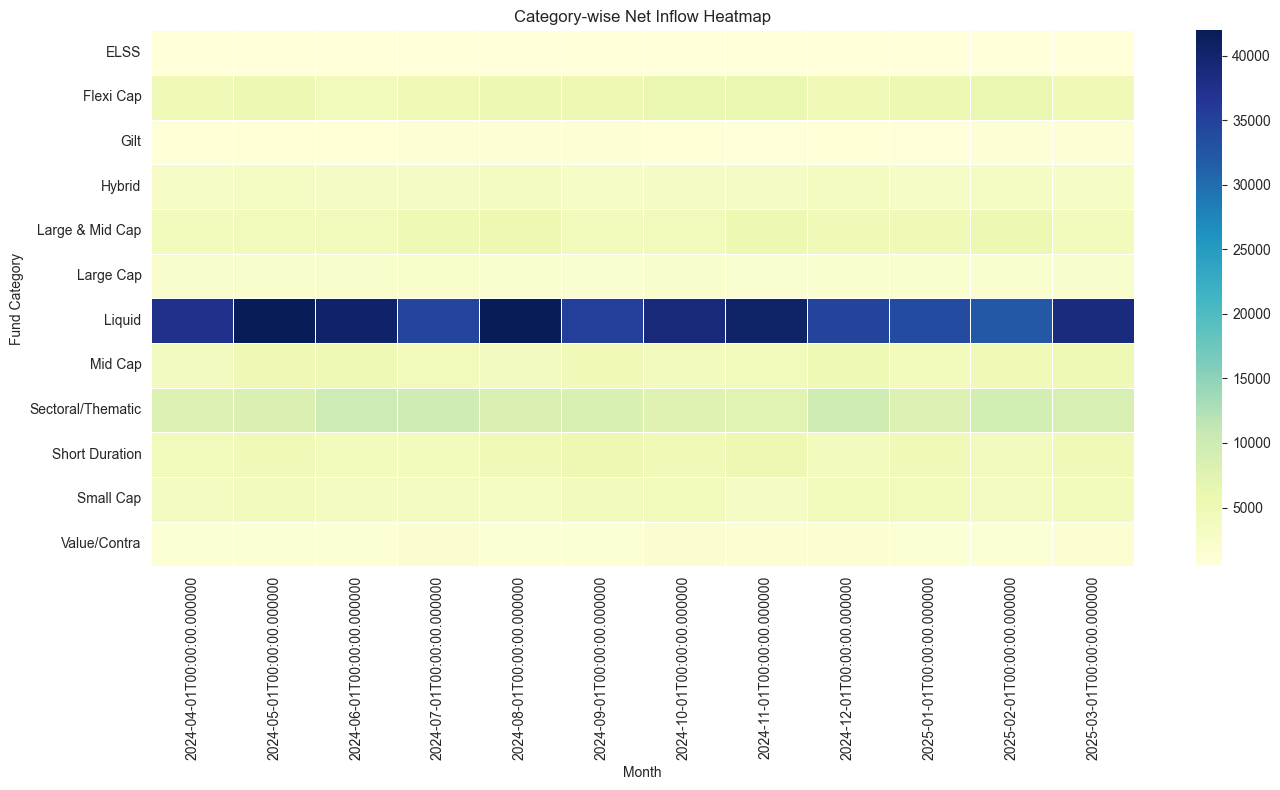

In [11]:
# CHART 4 - CATEGORY INFLOW HEATMAP

import seaborn as sns
import matplotlib.pyplot as plt

# Convert month column to date format
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

# Save chart
plt.savefig(
    "G:/bluestock_mf_capstone/reports/charts/chart_04_category_heatmap.png"
)

plt.show()

## Insight 5

The majority of mutual fund investors belong to a limited number of age groups, highlighting the primary demographic driving investments.

**Reference:** Chart 05 – Investor Age Group Distribution

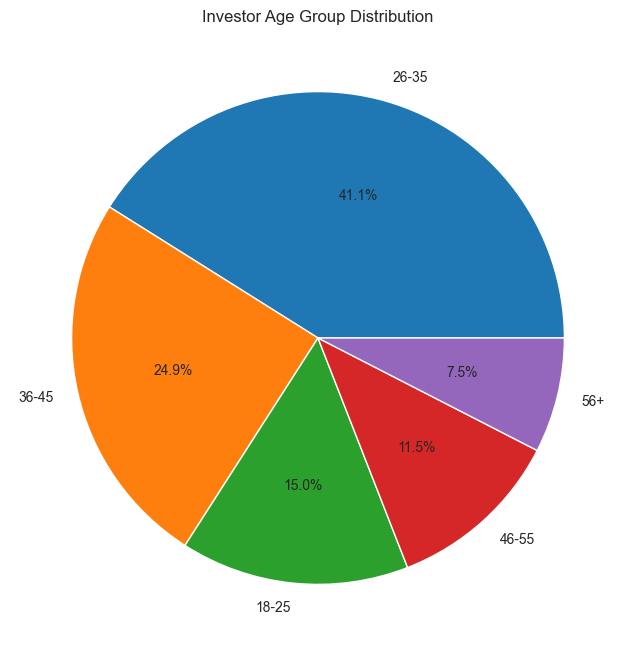

In [12]:
# CHART 5 - AGE GROUP DISTRIBUTION

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.savefig(
    "G:/bluestock_mf_capstone/reports/charts/chart_05_age_group_distribution.png"
)

plt.show()

## Insight 6

Investors from T30 cities contribute a larger share of mutual fund activity compared to B30 cities.

**Reference:** Chart 06 – T30 vs B30 Investor Distribution

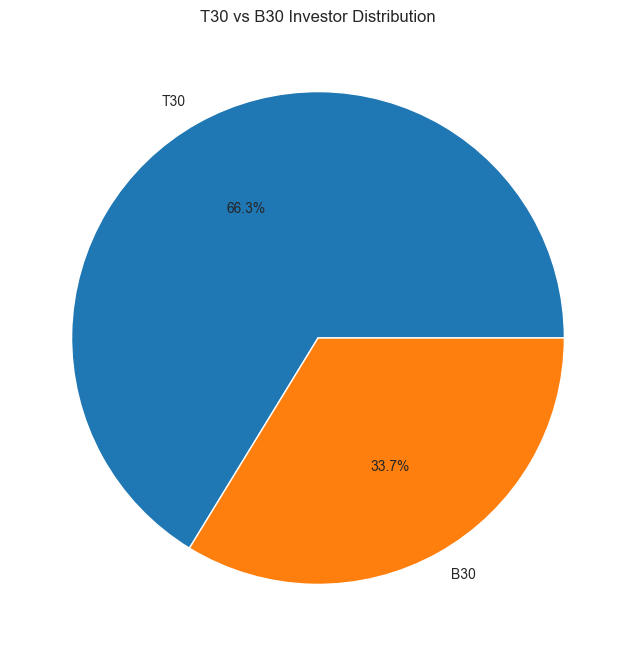

In [13]:
# CHART 6 - T30 VS B30 CITY TIER

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")
plt.ylabel("")

plt.savefig(
    "G:/bluestock_mf_capstone/reports/charts/chart_06_t30_vs_b30.png"
)

plt.show()

## Insight 7

Industry folio counts increased steadily from 2022 to 2025, indicating sustained growth in mutual fund adoption.

**Reference:** Chart 07 – Industry Folio Count Growth

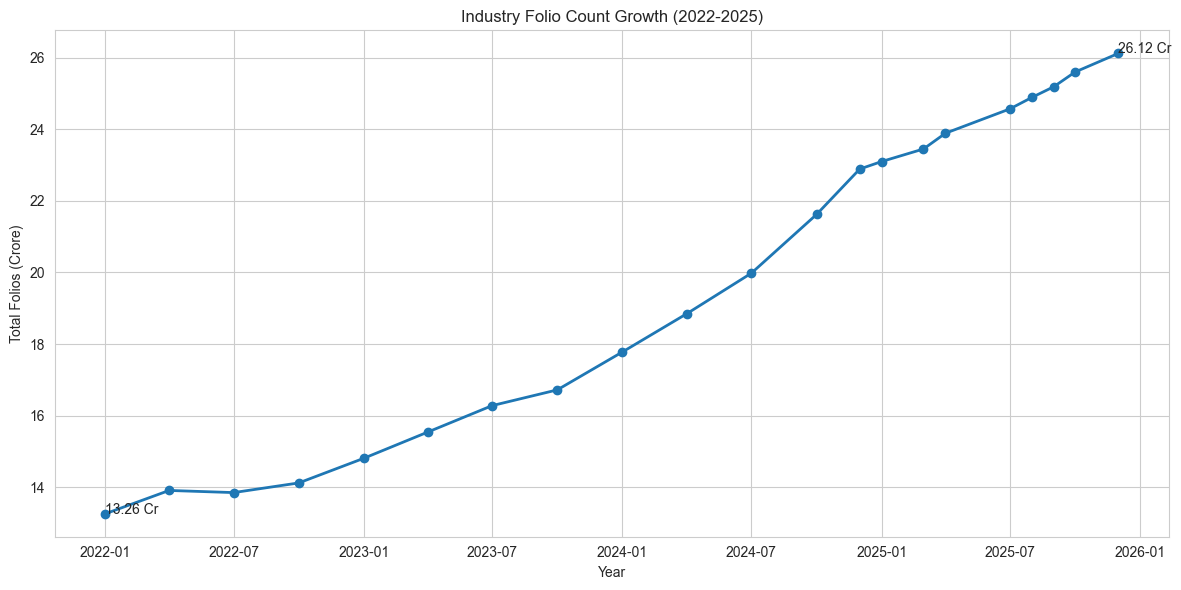

In [14]:
#CHART 7 - 
# FOLIO COUNT GROWTH
# Line chart from Jan 2022 to Dec 2025
# Mark key milestones

import matplotlib.pyplot as plt

# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

# Mark first point
plt.annotate(
    f"{folio.iloc[0]['total_folios_crore']} Cr",
    (folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"])
)

# Mark last point
plt.annotate(
    f"{folio.iloc[-1]['total_folios_crore']} Cr",
    (folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"])
)

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "G:/bluestock_mf_capstone/reports/charts/chart_07_folio_growth.png"
)
plt.show()

## Insight 8

Most selected mutual funds exhibit positive return correlations, suggesting common exposure to overall market movements.

**Reference:** Chart 08 – NAV Return Correlation Matrix

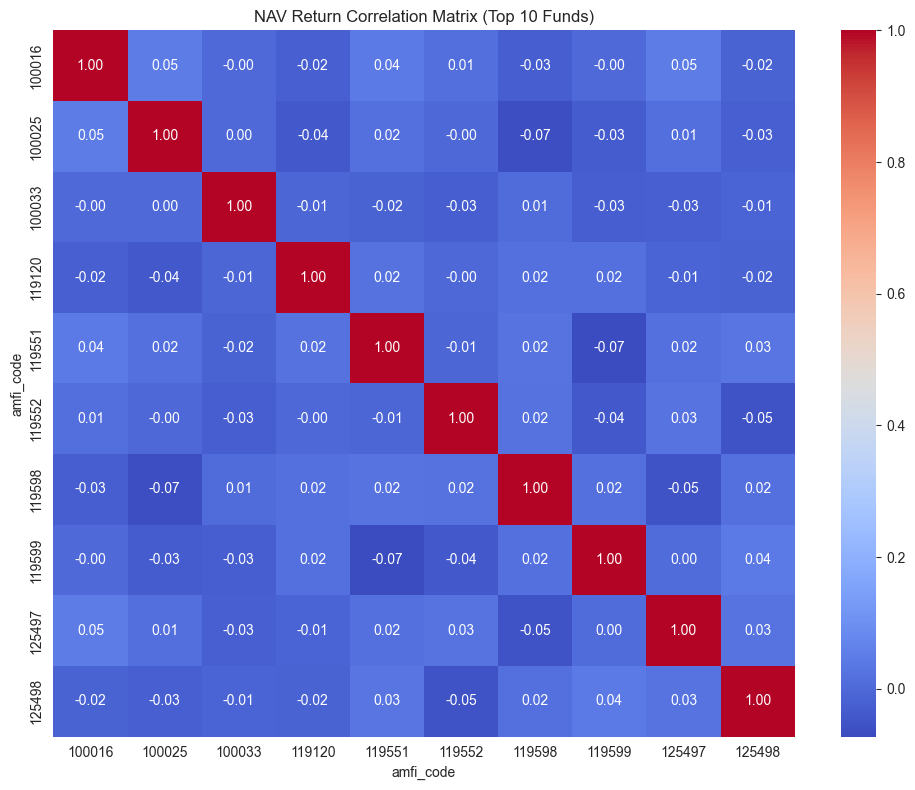

In [15]:
# CHART 8- NAV RETURN CORRELATION MATRIX
# Pairwise correlation of daily returns
# for 10 selected mutual funds

import seaborn as sns
import matplotlib.pyplot as plt

# Select first 10 funds
top10_funds = nav["amfi_code"].unique()[:10]

# Filter NAV data
corr_data = nav[
    nav["amfi_code"].isin(top10_funds)
]

# Create NAV matrix
pivot_nav = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily returns
daily_returns = pivot_nav.pct_change()

# Correlation matrix
corr_matrix = daily_returns.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix (Top 10 Funds)")

plt.tight_layout()
plt.savefig(
    "G:/bluestock_mf_capstone/reports/charts/chart_8_nav_correlation.png"
)
plt.show()

## Insight 9

Portfolio holdings are concentrated in a few dominant sectors, reflecting sector-specific investment strategies among fund managers.

**Reference:** Chart 09 – Sector Allocation Donut Chart

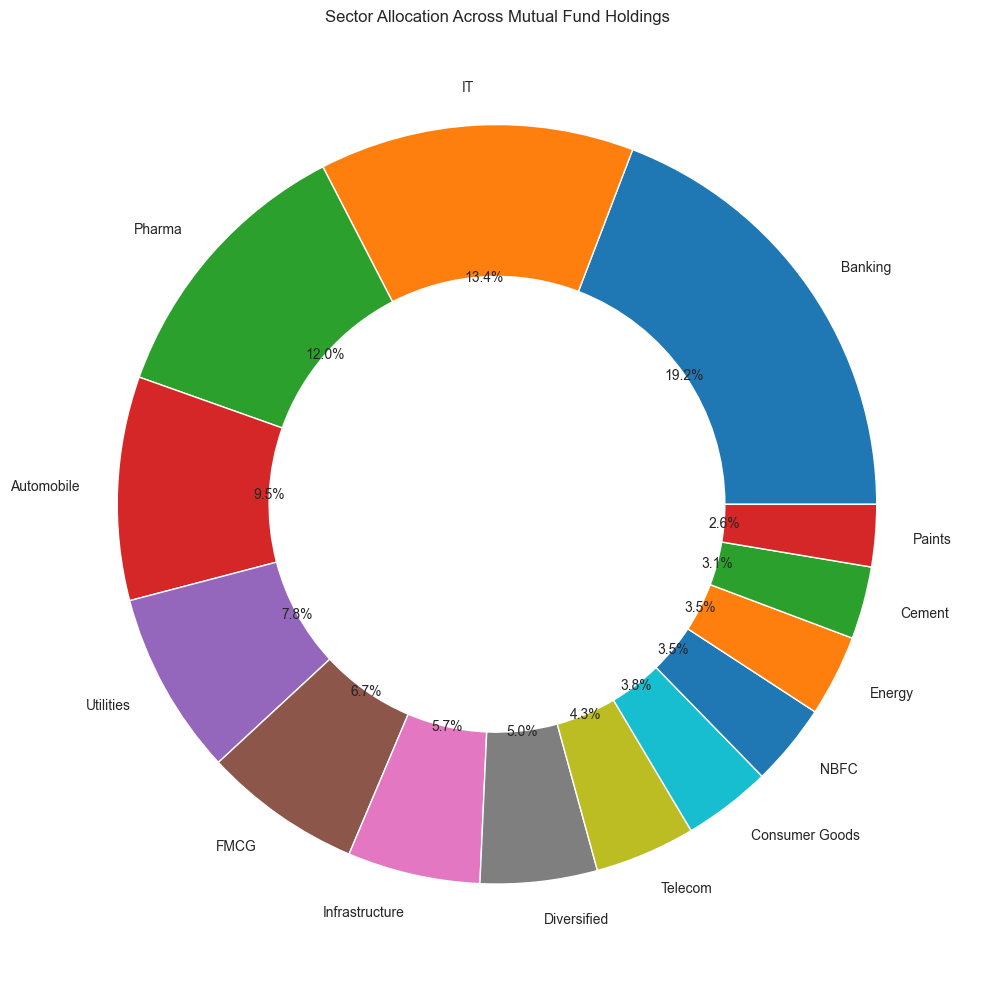

In [16]:
# CHART 9 - SECTOR ALLOCATION DONUT
# Aggregate sector weights across all equity funds

import matplotlib.pyplot as plt

# Aggregate sector weights
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Create donut chart
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Mutual Fund Holdings")

plt.tight_layout()
plt.savefig(
    "G:/bluestock_mf_capstone/reports/charts/chart_09_sector_donut.png"
)
plt.show()

## Insight 10

A small number of states contribute a disproportionately large share of total SIP investments.

**Reference:** Chart 10 – SIP Amount by State

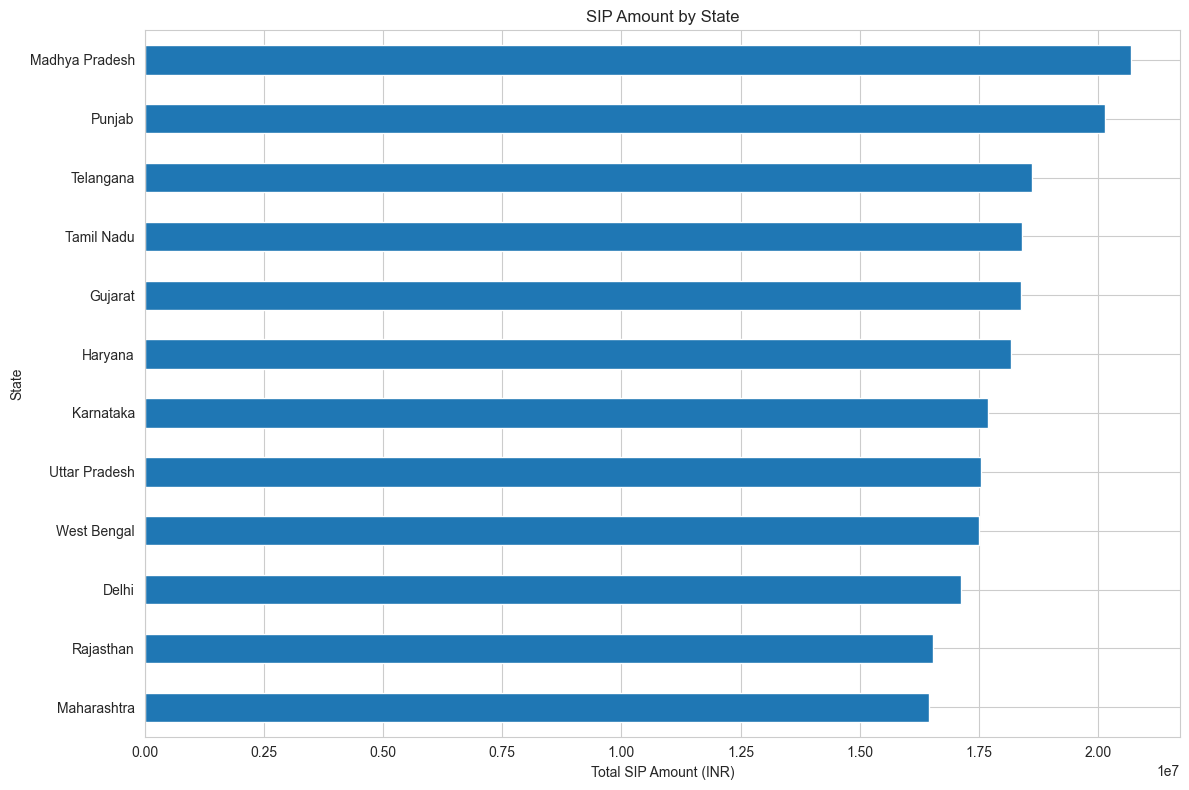

In [17]:
# CHART 10- SIP AMOUNT BY STATE

import matplotlib.pyplot as plt

# Keep only SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
]

# Total SIP amount by state
state_sip = (
    sip_transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))

state_sip.plot(kind="barh")

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "G:/bluestock_mf_capstone/reports/charts/chart_10_sip_by_state.png"
)

plt.show()